In [33]:
from src.OLS import OLS
from src.stat_tests import RESET, VIF, AR1, COOKS_D, CHOW, WALD

import pandas as pd
import numpy as np
np.set_printoptions(suppress=True, precision=6)

from scipy.stats import norm, t as t_dist
from statsmodels.graphics.tsaplots import plot_ccf

import matplotlib.pyplot as plt
import matplotlib as mpl

# mpl.rcParams['figure.dpi'] = 300 # uncomment when outputting figures for the paper
A4P = (8.27, 11.69)
A4L = (11.69, 8.27)

In [34]:
data_kw = {'encoding': 'utf-8', 'low_memory': False}

rgdp = pd.read_csv('data/fred/GDPC1.csv', **data_kw)
rgdp = rgdp.set_index('observation_date').rename(columns={'GDPC1': 'Y'})
rgdp.index = pd.to_datetime(rgdp.index)

pce = pd.read_csv('data/fred/PCECC96.csv', **data_kw)
pce = pce.set_index('observation_date').rename(columns={'PCECC96': 'pce'})
pce.index = pd.to_datetime(pce.index)
pce = pce.loc[rgdp.index]

pdi = pd.read_csv('data/fred/GPDIC1.csv', **data_kw)
pdi = pdi.set_index('observation_date').rename(columns={'GPDIC1': 'pdi'})
pdi.index = pd.to_datetime(pdi.index)
pdi = pdi.loc[rgdp.index]

govexp = pd.read_csv('data/fred/GCEC1.csv', **data_kw)
govexp = govexp.set_index('observation_date').rename(columns={'GCEC1': 'govexp'})
govexp.index = pd.to_datetime(govexp.index)
govexp = govexp.loc[rgdp.index]

odef = pd.read_csv('data/fred/GDPDEF.csv', **data_kw)
odef = odef.set_index('observation_date').rename(columns={'GDPDEF': 'odef'})
odef.index = pd.to_datetime(odef.index)
odef = odef.loc[rgdp.index]

unat = pd.read_csv('data/fred/NROU.csv', **data_kw)
unat = unat.set_index('observation_date').rename(columns={'NROU': 'u^*'})
unat.index = pd.to_datetime(unat.index)
unat = unat.loc[rgdp.index]

unrate = pd.read_csv('data/fred/LRUN64TTUSQ156S.csv', **data_kw)
unrate = unrate.set_index('observation_date').rename(columns={'LRUN64TTUSQ156S': 'u'})
unrate.index = pd.to_datetime(unrate.index)
unrate = unrate.loc[rgdp.index]

ugap = pd.DataFrame(
    {
    "ugap": unrate['u'] - unat['u^*']
    })
# ugap = ugap - ugap.mean()

gdp_pot = pd.read_csv('data/fred/GDPPOT.csv', **data_kw)
gdp_pot = gdp_pot.set_index('observation_date').rename(columns={'GDPPOT': 'Y^*'})
gdp_pot.index = pd.to_datetime(gdp_pot.index)
gdp_pot = gdp_pot.loc[rgdp.index]

ogap = pd.DataFrame({
    "ogap": np.log(rgdp['Y']) - np.log(gdp_pot['Y^*']),
})
# ogap = ogap - ogap.mean()

netexp = pd.read_csv('data/fred/NETEXP.csv', **data_kw)
netexp = netexp.set_index('observation_date').rename(columns={'NETEXP': 'NETEXP'})
netexp.index = pd.to_datetime(netexp.index)
netexp = netexp.loc[rgdp.index]
netexp['NETEXP'] = netexp['NETEXP'] / rgdp['Y']
# Interactions
okun = pd.DataFrame({
    "okun": ugap['ugap'] * ogap['ogap'],
})

phillips = pd.DataFrame({
    "phillips": ugap['ugap'] * np.log(odef['odef']).diff(),
})

shock_dates = (
    # pd.Timestamp("2020-07-01"),
    # pd.Timestamp("2020-04-01"),
    pd.Timestamp("2008-10-01"),
)

In [ ]:
target = np.log(rgdp).diff().dropna() * 100
fmt_regressors = [
    np.log(pce).diff().loc[target.index],
    np.log(pdi).diff().loc[target.index],
    np.log(govexp).diff().loc[target.index],
    # np.log(odef).diff().loc[target.index],
    
    ugap.loc[target.index].diff(),
    ogap.loc[target.index],

    okun.loc[target.index],    
    phillips.loc[target.index],
]
X = pd.concat(fmt_regressors, axis=1).shift(1).dropna()
t_idx = X.index
# shock_idx = [t_idx.get_loc(date) for date in shock_dates if date in t_idx]

# dummies = []
# for i, date in enumerate(shock_dates):
#     dummy = pd.Series(0, index=t_idx)
#     dummy.loc[date] = 1
#     dummy.name = f"dummy_{i+1}"
#     dummies.append(dummy)
# X = pd.concat([X] + dummies, axis=1)
# t_idx = t_idx[:-21]\
    # .where(~t_idx[:-21].isin(shock_dates)).dropna()

X = X.loc[t_idx]
y = target.loc[t_idx]

In [36]:
fit = OLS(
    X=X.values,
    y=y.values.flatten(),
).fit(diagnosis_alpha=0.05, diagnosis_trend='n')
fit.error

R2: 0.4071
R2_ADJ: 0.3703
RMSE: 0.864
MAPE: 0.9993

In [60]:
VIF(X).round(2)

array([4.79, 2.06, 1.53, 9.22, 3.94, 4.63, 3.22])

In [38]:
RESET(
    X=X,
    y=y.values.flatten(),
    q=2
)

reject: True
pval: 2.3359092438113294e-13
test_stat: 36.82048163270007
stat_name: RESET Test (F-Statistic)

In [39]:
t = {'_const': fit.T_tests[0]}
for i, var in enumerate(X.columns):
    t[var] = fit.T_tests[i+1]
{k: round(v.pval, 4) for k, v in t.items()}

{'_const': 0.831,
 'pce': 0.0,
 'pdi': 0.0023,
 'govexp': 0.073,
 'ugap': 0.0,
 'ogap': 0.5201,
 'okun': 0.067,
 'phillips': 0.0315}

In [64]:
fit.intercept.round(4), fit.coefs.round(4).astype(float)

(np.float64(0.0288),
 array([ 76.83  ,   9.7348, -22.6115,   1.1538,  -5.0182,  -3.4977,
        -32.7522]))

In [41]:
fit.F_test

reject: True
pval: 8.077538637962789e-12
test_stat: 11.070374552342525
stat_name: F Test (F-Statistic)

In [42]:
fit.XT_e

np.float64(-8.49325492748021e-14)

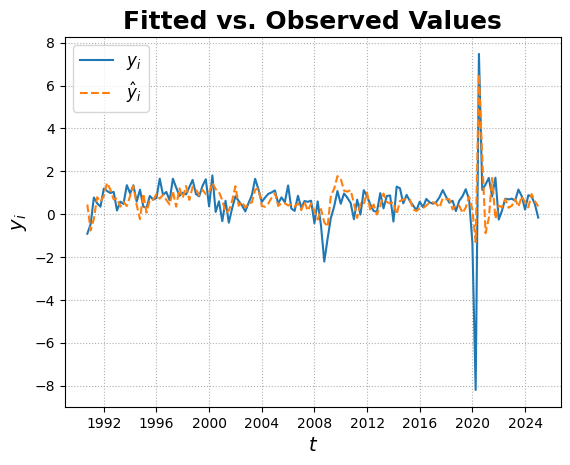

In [43]:
plt.plot(t_idx, y, label=r"$y_i$")
plt.plot(t_idx, fit.fitted_values, label=r"$\hat{y}_i$", linestyle='--')


plt.title(r"Fitted vs. Observed Values", fontsize=18, weight='bold')
plt.grid(alpha=1, linestyle=":")
plt.tick_params(axis="x", rotation=0, labelsize=10)
plt.tick_params(axis="y", rotation=0, labelsize=10)

plt.ylabel(r"$y_i$", fontsize=14)
plt.xlabel(r"$t$", fontsize=14)

plt.legend(fontsize=12)
# plt.savefig('paper2/fig/fit_v_obs.png', dpi=300)
plt.show()

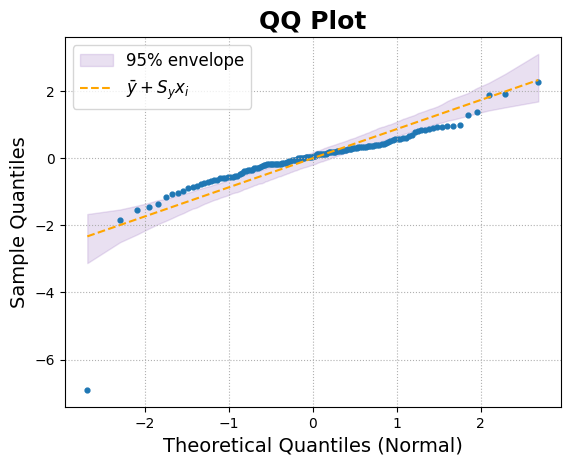

reject: True
pval: 3.6254207335860765e-14
test_stat: 0.7458938170439559
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [44]:
fit.qq(line='45')
fit.resid_normality

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
C:\Users\guney\AppData\Local\Temp\ipykernel_68156\1366682432.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")
C:\Users\guney\AppData\Local\Temp\ipykernel_68156\1366682432.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")


Text(0.5, 0.98, 'Distributions of Regressors')

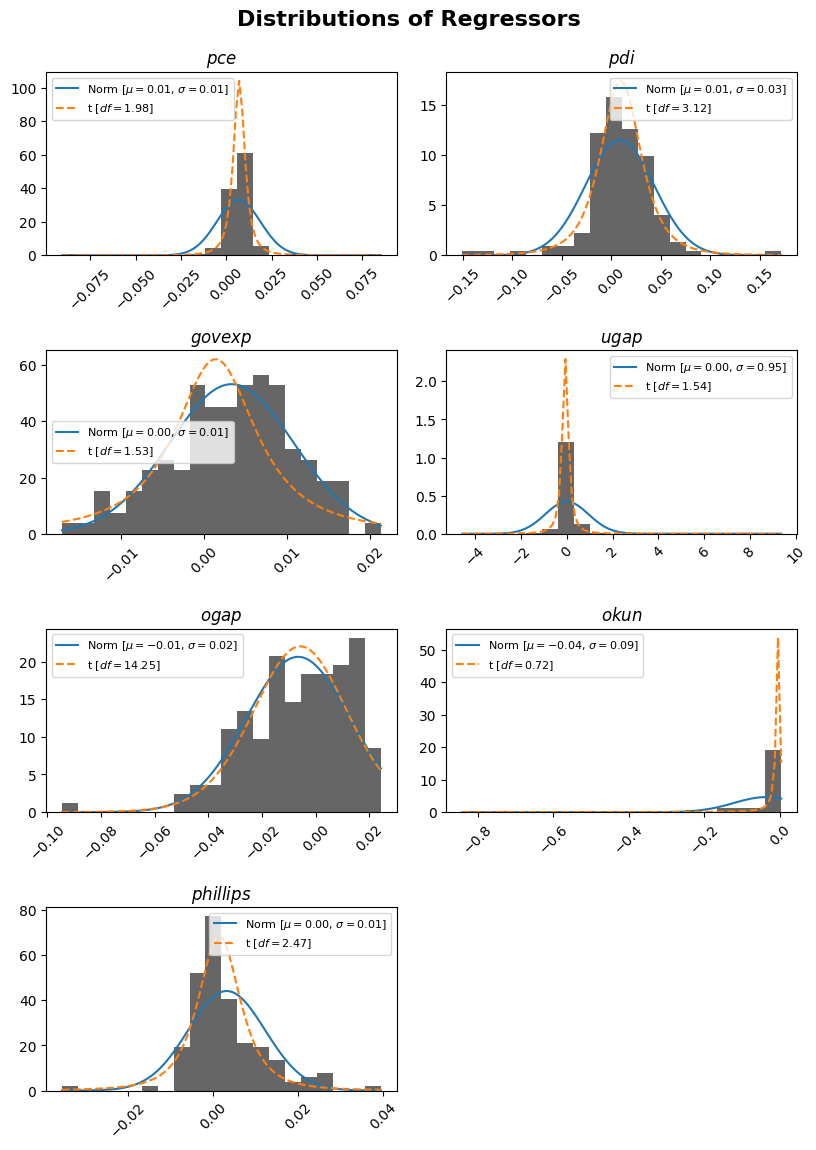

In [45]:
fig, ax = plt.subplots(4, 2, figsize=A4P)
ax = ax.flatten()
while len(ax) > len(X.columns):
    fig.delaxes(ax[-1])
    ax = ax[:-1]

for i, v in enumerate(X.columns):
    ax[i].hist(X[v], bins=20, density=True, alpha=0.6, color='black')
    xmin, xmax = X[v].min(), X[v].max()
    x = np.linspace(xmin, xmax, 100)
    mu, std = norm.fit(X[v])
    gaus_fit = norm.pdf(x, mu, std)
    ts = t_dist.fit(X[v])
    t_fit = t_dist.pdf(x, *ts)

    ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")
    ax[i].plot(x, t_fit, label=f"t [$df={ts[0]:,.2f}$]", linestyle='--')
    ax[i].set_title(fr"${v}$")
    ax[i].tick_params(axis="x", rotation=45)
    ax[i].legend(fontsize=8, loc='best')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle("Distributions of Regressors", fontsize=16, weight='bold')

Text(0.5, 0.98, 'CCF Plots of Whitened Regressors and Dependent Variable')

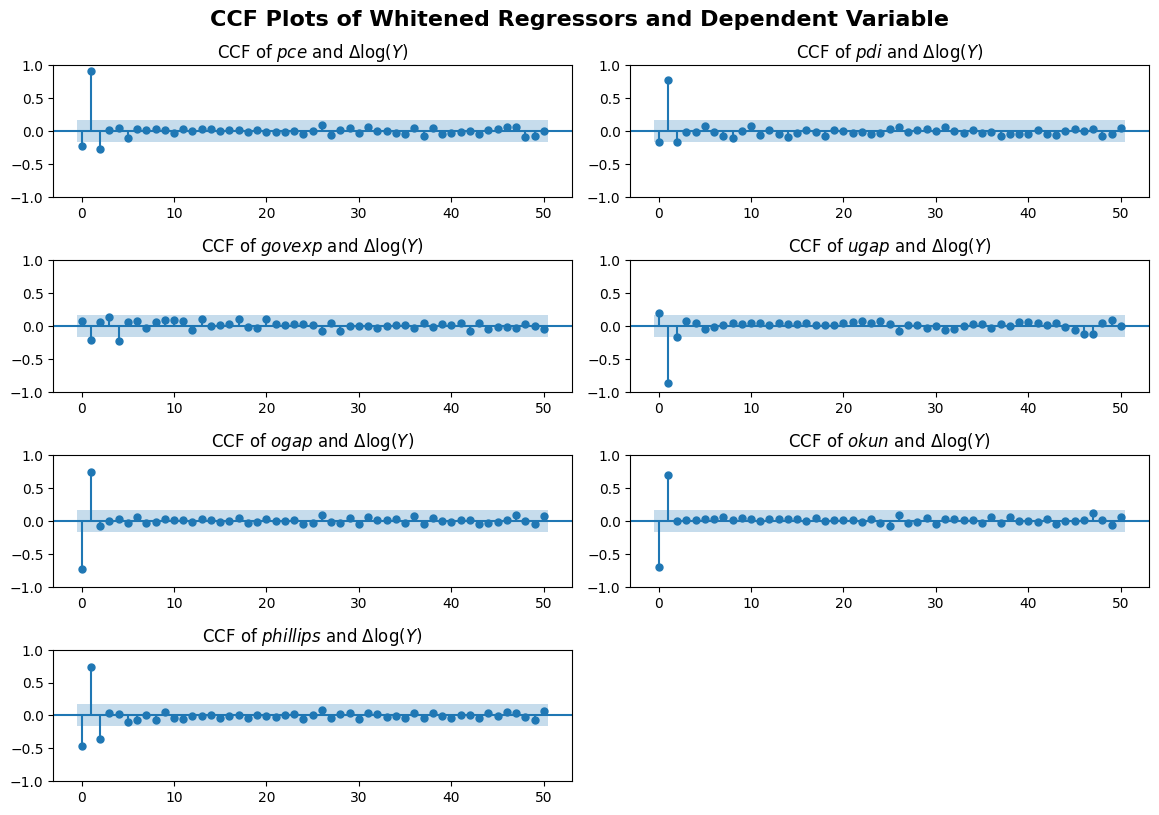

In [65]:
fig, ax = plt.subplots(4, 2, figsize=A4L)
ax = ax.flatten()
while len(ax) > len(X.columns):
    fig.delaxes(ax[-1])
    ax = ax[:-1]
    
for i, v in enumerate(X.columns):
    coef = AR1(X[v].values, 'n')
    resid = X[v].values[1:] - coef * X[v].values[:-1]
    target = y.values[1:] - coef * y.values[:-1]
    plot_ccf(resid, target, lags=50, ax=ax[i], title=fr"CCF of ${v}$ and $\Delta \log(Y)$")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle("CCF Plots of Whitened Regressors and Dependent Variable", fontsize=16, weight='bold')
# fig.savefig('paper2/fig/ccf.png', dpi=300)

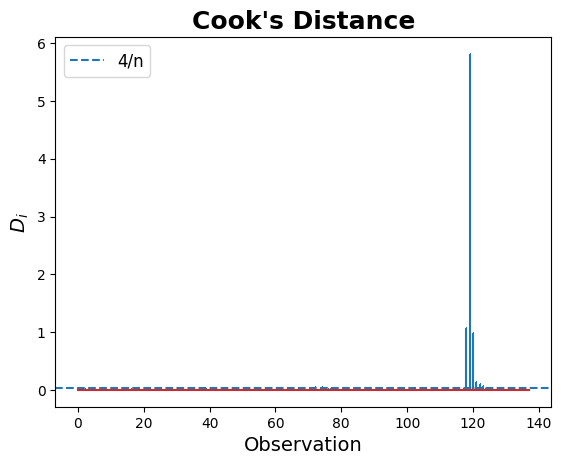

DatetimeIndex(['2008-10-01', '2009-04-01', '2010-01-01', '2020-04-01',
               '2020-07-01', '2020-10-01', '2021-01-01', '2021-04-01',
               '2021-07-01', '2021-10-01'],
              dtype='datetime64[ns]', name='observation_date', freq=None)

In [66]:
D, *_ = COOKS_D(
    X=X,
    y=y.values.flatten(),
    intercept=True,
    plot=True
)

obs = np.where(D > 4/len(t_idx))
t_idx[obs]

In [48]:
fit.resid_normality

reject: True
pval: 3.6254207335860765e-14
test_stat: 0.7458938170439559
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [49]:
fit.resid_heteroske

reject: False
pval: 0.9846470299222229
test_stat: 17.336082862225872
stat_name: Breusch-Pagan Test (Chi^2 Statistic)

In [67]:
fit.resid_autocorr

[reject: True
 pval: 0.0
 test_stat: -0.01806132239828684
 stat_name: BG(1) Test (Chi^2 Statistic),
 reject: False
 pval: 0.787872946491997
 test_stat: 3.101139749648058
 stat_name: BG(2) Test (Chi^2 Statistic),
 reject: False
 pval: 0.75975761101241
 test_stat: 4.204193326013336
 stat_name: BG(3) Test (Chi^2 Statistic),
 reject: False
 pval: 0.966013141163342
 test_stat: 10.415094342684498
 stat_name: BG(4) Test (Chi^2 Statistic),
 reject: False
 pval: 0.961407520319077
 test_stat: 11.735825031867174
 stat_name: BG(5) Test (Chi^2 Statistic),
 reject: False
 pval: 0.942763822443006
 test_stat: 12.220041073556036
 stat_name: BG(6) Test (Chi^2 Statistic),
 reject: False
 pval: 0.898406189628808
 test_stat: 11.968672442767263
 stat_name: BG(7) Test (Chi^2 Statistic),
 reject: False
 pval: 0.85337113388861
 test_stat: 12.10387959588957
 stat_name: BG(8) Test (Chi^2 Statistic)]

In [51]:
fit.resid_stationarity

reject: True
pval: 0.0010588681369383957
test_stat: -3.2772919447932662
stat_name: ADF Test (T-Statistic)

In [52]:
np.linalg.cond(X)

np.float64(214.13505046692208)

In [58]:
CHOW(
    X=X,
    y=y.values.flatten(),
    t_break=X.index.get_loc(pd.Timestamp("2020-04-01")),
), CHOW(
    X=X,
    y=y.values.flatten(),
    t_break=X.index.get_loc(pd.Timestamp("2020-07-01")),
), CHOW(
    X=X,
    y=y.values.flatten(),
    t_break=X.index.get_loc(pd.Timestamp("2020-10-01")),
),CHOW(
    X=X,
    y=y.values.flatten(),
    t_break=X.index.get_loc(pd.Timestamp("2008-10-01")),
),

(reject: True
 pval: 0.009750314847907893
 test_stat: 2.797508075418492
 stat_name: Chow test (F-Statistic),
 reject: True
 pval: 3.204381819554847e-06
 test_stat: 6.187178283978163
 stat_name: Chow test (F-Statistic),
 reject: True
 pval: 0.006700017671038894
 test_stat: 2.957161354056569
 stat_name: Chow test (F-Statistic),
 reject: False
 pval: 0.693195169754732
 test_stat: 0.6746373370651813
 stat_name: Chow test (F-Statistic))